# FCI Energy Caching for Diatomic and Small Molecules

This notebook demonstrates the computation and caching of FCI energies for small molecules using PYSCF-Based solvers.

We evaluate:
- $H_2$
- $LiH$
- $Li_2O$

The results are stored in `data` for later use in VQE pipeline

In [1]:
from src.data.cache import cache_fci
from src.utils.generate_distance_grid import generate_distance_grid
from src.visualization.plots import plot_fci

## $H_2$

In [2]:
def h2_geom(d):
    return f"H 0 0 0; H 0 0 {d}"

for basis in ["sto-3g", "6-31g", "cc-pvdz"]:
    distances = generate_distance_grid(
        geometry_fn=h2_geom,
        basis=basis
    )
    cache_fci("H2", basis=basis, geometry_fn=h2_geom, distances=distances)

Coarse scan...
Estimated equilibrium distance: 0.6875 Å
Fine grid: [0.344, 2.062] with 100 points
[1/100] d=0.3438 E=-0.76984937 (FCI) orb=2 ⏱ 0.0s
[2/100] d=0.3611 E=-0.82146404 (FCI) orb=2 ⏱ 0.0s
[3/100] d=0.3785 E=-0.86637682 (FCI) orb=2 ⏱ 0.1s
[4/100] d=0.3958 E=-0.90552334 (FCI) orb=2 ⏱ 0.1s
[5/100] d=0.4132 E=-0.93968062 (FCI) orb=2 ⏱ 0.1s
[6/100] d=0.4306 E=-0.96949857 (FCI) orb=2 ⏱ 0.1s
[7/100] d=0.4479 E=-0.99552451 (FCI) orb=2 ⏱ 0.1s
[8/100] d=0.4653 E=-1.01822232 (FCI) orb=2 ⏱ 0.2s
[9/100] d=0.4826 E=-1.03798760 (FCI) orb=2 ⏱ 0.3s
[10/100] d=0.5000 E=-1.05515979 (FCI) orb=2 ⏱ 0.3s
[11/100] d=0.5174 E=-1.07003187 (FCI) orb=2 ⏱ 0.3s
[12/100] d=0.5347 E=-1.08285813 (FCI) orb=2 ⏱ 0.3s
[13/100] d=0.5521 E=-1.09386058 (FCI) orb=2 ⏱ 0.4s
[14/100] d=0.5694 E=-1.10323399 (FCI) orb=2 ⏱ 0.4s
[15/100] d=0.5868 E=-1.11115012 (FCI) orb=2 ⏱ 0.4s
[16/100] d=0.6042 E=-1.11776111 (FCI) orb=2 ⏱ 0.4s
[17/100] d=0.6215 E=-1.12320222 (FCI) orb=2 ⏱ 0.4s
[18/100] d=0.6389 E=-1.12759418 (FCI) orb=2 

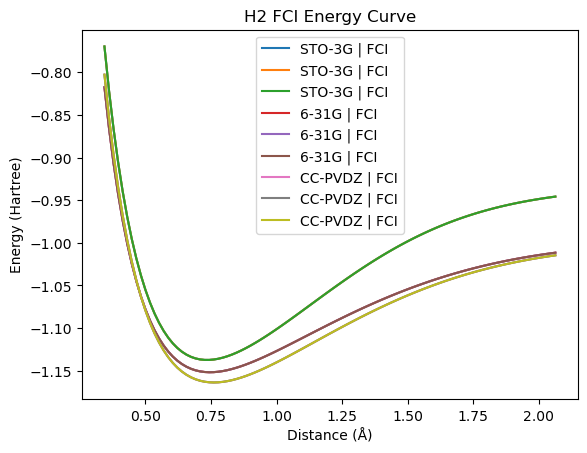

In [3]:
plot_fci("H2", basis=["sto-3g", "6-31g", "cc-pvdz"])

## $LiH$

In [ ]:
def lih_geom(d):
    return f"Li 0 0 0; H 0 0 {d}"

for basis in ["sto-3g", "6-31g", "cc-pvdz"]:
    distances = generate_distance_grid(
        geometry_fn=lih_geom,
        basis=basis
    )
    cache_fci("LiH", basis=basis, geometry_fn=lih_geom, distances=distances, freeze_core=1)

In [ ]:
plot_fci("LiH", basis=["sto-3g", "6-31g", "cc-pvdz"])

## $Li_2O$ (simplified linear)

In [ ]:
def li2o_geom_linear(d):
    return f"Li 0 0 {-d}; O 0 0 0; Li 0 0 {d}"

for basis in ["sto-3g", "6-31g", "cc-pvdz"]:
    distances = generate_distance_grid(
        geometry_fn=li2o_geom_linear,
        basis=basis,
        active_space=(8, 6)
    )
    cache_fci(
        "Li2O_linear", 
        basis=basis, 
        geometry_fn=li2o_geom_linear, 
        distances=distances, 
        freeze_core=3,
        active_space=(8, 6)
    )

In [ ]:
plot_fci("Li2O_linear", basis=["sto-3g", "6-31g", "cc-pvdz"])

In [ ]:
# Analysis of Li2O angular geometry yielded irrelevant results

def li2o_geom_angular(d, angle_deg=120):
    import numpy as np

    theta = np.radians(angle_deg / 2)

    x = d * np.sin(theta)
    z = d * np.cos(theta)

    return f"Li {x} 0 {z}; O 0 0 0; Li {-x} 0 {z}"

for basis in ["sto-3g", "6-31g", "cc-pvdz"]:
    distances = generate_distance_grid(
        geometry_fn=li2o_geom_linear,
        basis=basis
    )
    cache_fci(
        "Li2O_angular",
        basis=basis,
        geometry_fn=li2o_geom_linear,
        distances=distances,
        freeze_core=3
    )

for basis in ["sto-3g", "6-31g", "cc-pvdz"]:
    plot_fci("Li2O_angular", basis=basis, show=False)